In [1]:
# import eckit.geo
# from earthkit.data.field.component.geography import Geography

## Regridding data

healpix-h128-nested-2t.grib:   0%|          | 0.00/385k [00:00<?, ?B/s]

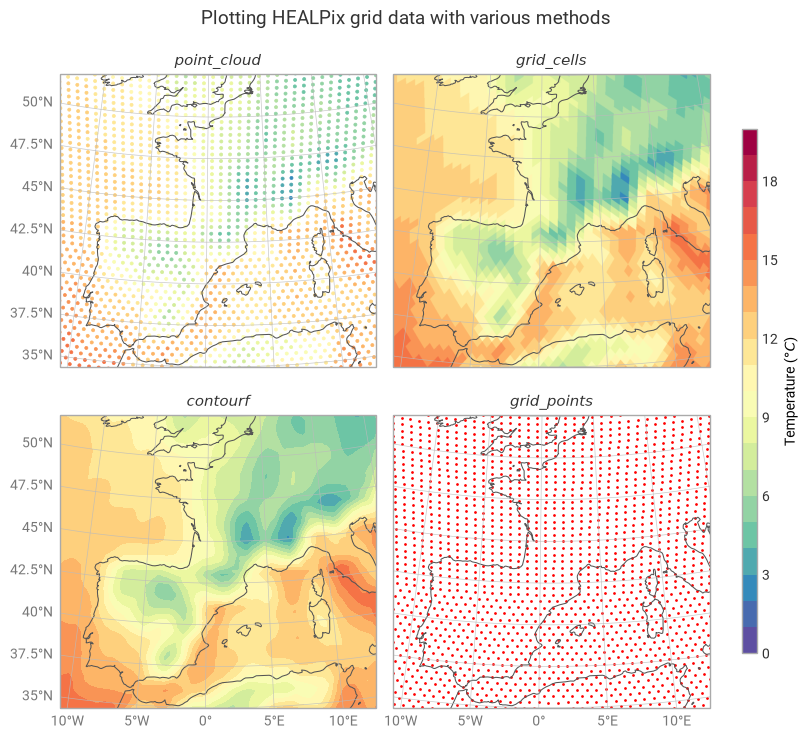

In [2]:
import earthkit.data as ekd

import earthkit.plots as ekp

data = ekd.from_source("sample", "healpix-h128-nested-2t.grib")

figure = ekp.Figure(rows=2, columns=2, domain=["France", "Spain"])

style = ekp.styles.Style(
    levels=range(0, 21),
    colors="Spectral_r",
    units="celsius",
)

for method in ["point_cloud", "grid_cells", "contourf"]:
    subplot = figure.add_map()
    getattr(subplot, method)(data, style=style)
    subplot.title(f"${method}$".replace("_", r"\_"))

subplot = figure.add_map()
subplot.grid_points(data)
subplot.title(r"$grid\_points$")

figure.coastlines()
figure.gridlines()

figure.title("Plotting HEALPix grid data with various methods")

figure.legend(location="right")

figure.show()

O32.grib:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

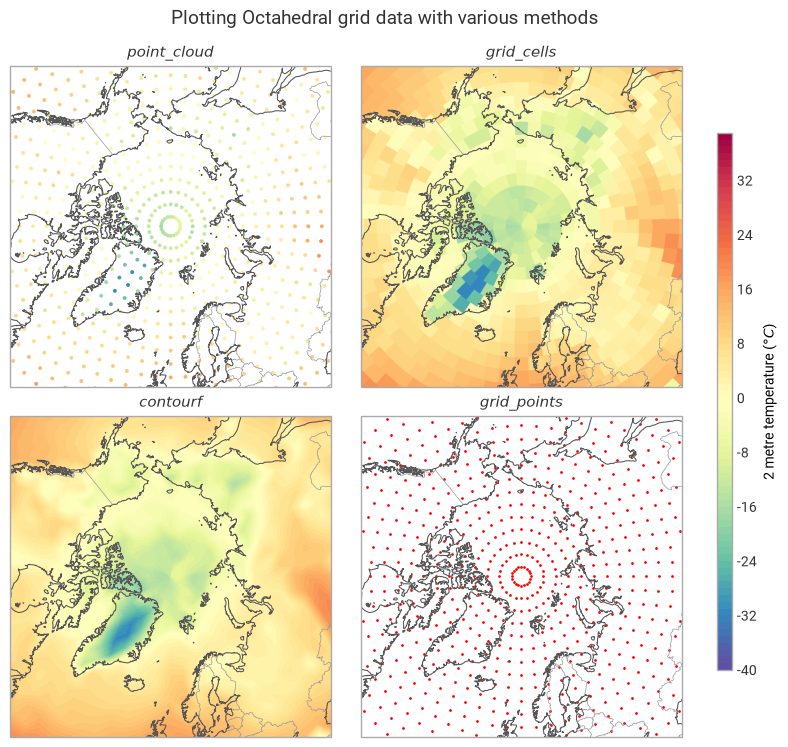

In [3]:
data = ekd.from_source(
    "url",
    "https://get.ecmwf.int/repository/test-data/earthkit-regrid/test-data/global_0_360/O32.grib",
)

figure = ekp.Figure(rows=2, columns=2, domain="Arctic")

style = ekp.styles.Style(
    levels=range(-40, 40),
    colors="Spectral_r",
    units="celsius",
)

for method in ["point_cloud", "grid_cells", "contourf"]:
    subplot = figure.add_map()
    getattr(subplot, method)(data, style=style)
    subplot.title(f"${method}$".replace("_", r"\_"))

subplot = figure.add_map()
subplot.grid_points(data)
subplot.title(r"$grid\_points$")

figure.title("Plotting Octahedral grid data with various methods")

figure.coastlines()
figure.borders()
figure.legend(location="right")

figure.show()

### What if I don't have the right metadata?

In [4]:
data = ekd.from_source("sample", "healpix-h128-ring-2t.grib")
ds = data.to_xarray()
ds.t.attrs.pop("_earthkit")
ds

healpix-h128-ring-2t.grib:   0%|          | 0.00/385k [00:00<?, ?B/s]

<xarray.Dataset> Size: 5MB
Dimensions:    (values: 196608)
Coordinates:
    latitude   (values) float64 2MB ...
    longitude  (values) float64 2MB ...
Dimensions without coordinates: values
Data variables:
    t          (values) float64 2MB ...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

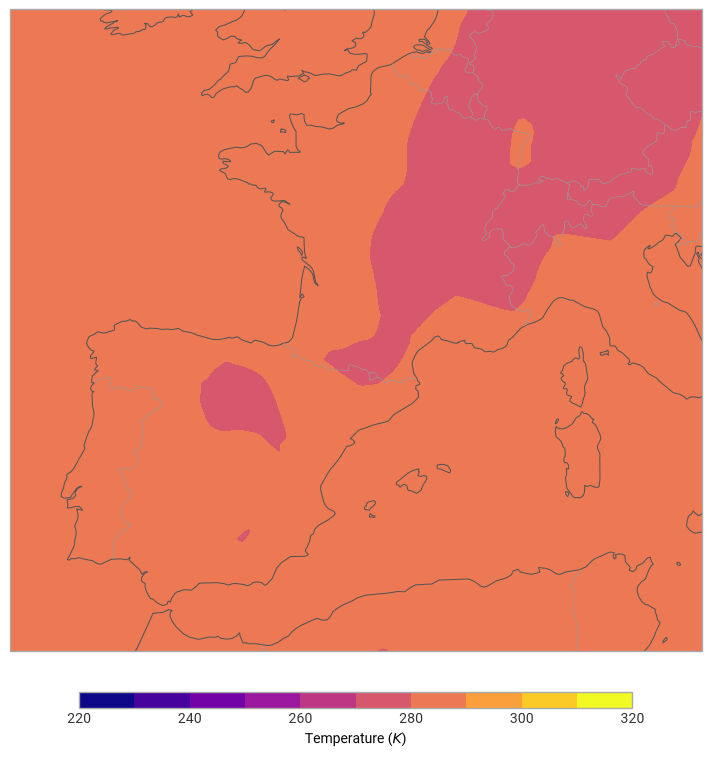

In [5]:
from earthkit.plots.resample import Regrid

chart = ekp.Map(domain=["France", "Spain"])

chart.contourf(ds, resample=Regrid(in_grid={"grid": "H128", "order": "ring"}))

chart.legend()

chart.coastlines()
chart.borders()

chart.show()